<font size="+3"><strong>1.5. Housing in Brazil 🇧🇷</strong></font>

In [2]:
# Import Matplotlib, pandas, and plotly
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
%matplotlib inline

In [3]:
# Load csv and read with pandas
df1 = pd.read_csv("./data/brasil-real-estate-1.csv")
df1.head()
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  str    
 1   place_with_parent_names  12834 non-null  str    
 2   region                   12834 non-null  str    
 3   lat-lon                  11551 non-null  str    
 4   area_m2                  12834 non-null  float64
 5   price_usd                12834 non-null  str    
dtypes: float64(1), str(5)
memory usage: 601.7 KB


In [4]:
# Drop empty columns
df1.dropna(inplace = True)
df1.info()

<class 'pandas.DataFrame'>
Index: 11551 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            11551 non-null  str    
 1   place_with_parent_names  11551 non-null  str    
 2   region                   11551 non-null  str    
 3   lat-lon                  11551 non-null  str    
 4   area_m2                  11551 non-null  float64
 5   price_usd                11551 non-null  str    
dtypes: float64(1), str(5)
memory usage: 631.7 KB


In [5]:
# Split the lat-lon columns into two columns namely lat and lon
df1[["lat", "lon"]] = df1["lat-lon"].str.split(",", expand=True).astype(float)
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85",-9.644305,-35.708814
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37",-9.643093,-35.704840
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45",-9.622703,-35.729795
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20",-9.622837,-35.719556
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71",-9.654955,-35.700227


In [6]:
# create new column and store the third value of the place_with_parent_names array
df1["state"] = df1["place_with_parent_names"].str.split("|", expand=True)[2]
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon,state
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85",-9.644305,-35.708814,Alagoas
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37",-9.643093,-35.704840,Alagoas
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45",-9.622703,-35.729795,Alagoas
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20",-9.622837,-35.719556,Alagoas
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71",-9.654955,-35.700227,Alagoas


In [7]:
# Remove $ and "," from the price_usd column and set the type as float
df1["price_usd"] = df1["price_usd"].str.replace("$", "", regex=False).str.replace(",","").astype(float)
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon,state
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,101416.71,-9.654955,-35.700227,Alagoas


In [8]:
# Drop the lat-lon and place_with_parent_names columns
df1.drop(columns = ["lat-lon", "place_with_parent_names"], inplace=True)
df1.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


In [9]:
# Read another csv file
df2 = pd.read_csv("./data/brasil-real-estate-2.csv")
df2.head()
df2.info()
df2.shape

<class 'pandas.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  12833 non-null  str    
 1   state          12833 non-null  str    
 2   region         12833 non-null  str    
 3   lat            12833 non-null  float64
 4   lon            12833 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      12833 non-null  float64
dtypes: float64(4), str(3)
memory usage: 701.9 KB


(12833, 7)

In [10]:
# create new column and convert price_brl to usd equivalent
df2["price_usd"] = df2["price_brl"] / 3.19
df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98,129850.463950
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53,265958.786834
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28,93867.799373
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53,265958.786834
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36,145495.097179


In [11]:
# combine two dataframes together
df = pd.concat([df1, df2])
print("df shape:", df.shape)
df.head()

df shape: (24384, 8)


,property_type,region,area_m2,price_usd,lat,lon,state,price_brl
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas,NaN
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas,NaN
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas,NaN
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas,NaN
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas,NaN


In [12]:
# drop price_brl
df2.dropna(inplace=True)
df2.drop(columns = ["price_brl"], inplace = True)
df2.head()

,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,129850.463950
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,265958.786834
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,93867.799373
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,265958.786834
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,145495.097179


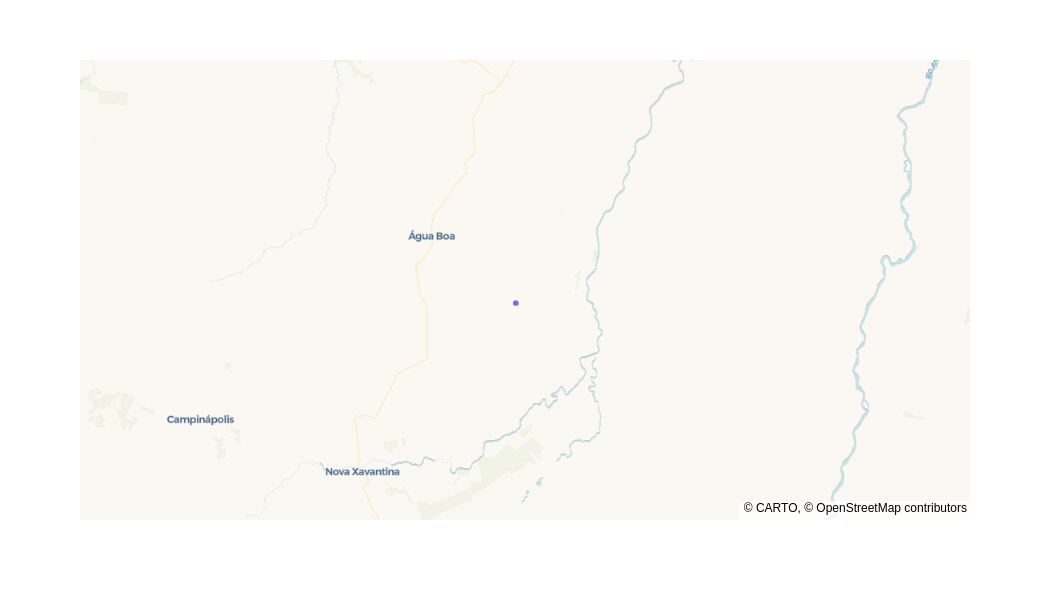

In [17]:
fig = px.scatter_map(
    df,
    lat=df["lat"],  
    lon=df["lon"], 
    center={"lat": -14.2, "lon": -51.9},  # Map will be centered on Brazil
    width=600,
    height=600,
    hover_data=["price_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

In [19]:
# get a summary of the new dataframe
summary_stats = df[["area_m2", "price_usd"]].describe()
summary_stats

,area_m2,price_usd
count,22844.000000,24384.000000
mean,115.020224,195891.733957
std,47.742932,104169.206335
min,53.000000,74892.340000
25%,76.000000,114205.830721
50%,103.000000,165833.119122
75%,142.000000,248749.686520
max,252.000000,525659.717868


Text(0.5, 1.0, 'Distribution of Home Prices')

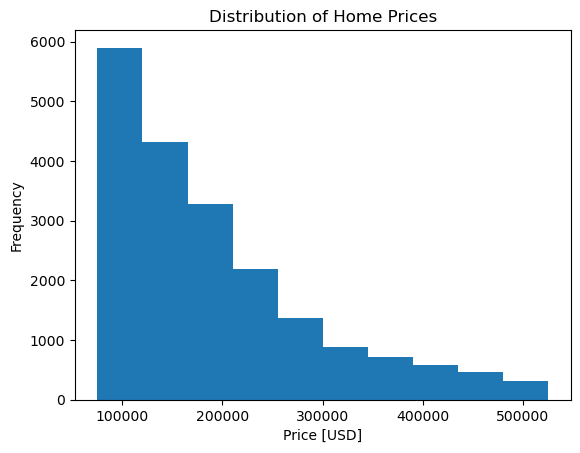

In [20]:
# A histogram showing the first 20000 columns showing the freq distribution of home prices
fig, ax = plt.subplots()

# Build histogram
ax.hist(df["price_usd"].iloc[:20000])

# Label axes
plt.xlabel("Price [USD]")
plt.ylabel("Frequency")

# Add title
plt.title("Distribution of Home Prices")

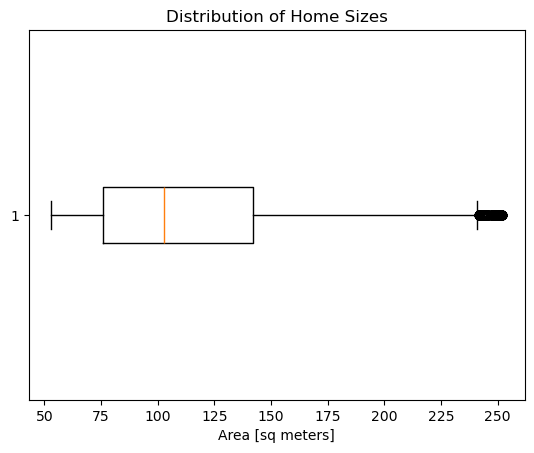

In [21]:
area = pd.to_numeric(df["area_m2"], errors="coerce").dropna()

fig, ax = plt.subplots()

ax.boxplot(area, vert=False)
ax.set_xlabel("Area [sq meters]")
ax.set_title("Distribution of Home Sizes")

plt.show()

In [22]:
# create a series that groups each region with price
mean_price_by_region = df.groupby("region")["price_usd"].mean().sort_values(ascending = True)
mean_price_by_region

region
Central-West    178596.283663
North           181259.036146
Northeast       185138.544328
South           190552.405489
Southeast       209635.188534
Name: price_usd, dtype: float64

<Axes: title={'center': 'Mean Home Price by Region'}, xlabel='Region', ylabel='Mean Price [USD]'>

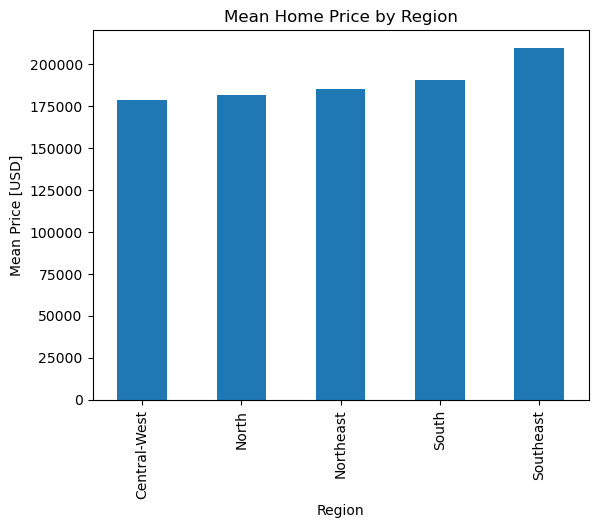

In [23]:
# create a histogram that shows the mean price against region
fig, ax = plt.subplots()
# Build bar chart, label axes, add title
mean_price_by_region.plot(
    kind="bar",
    xlabel="Region",
    ylabel="Mean Price [USD]",
    title="Mean Home Price by Region"
    , ax=ax)

In [28]:
# create new dataframe of states in south region
df_south = df[df["region"] == "South"]
df_south.head()

,property_type,region,area_m2,price_usd,lat,lon,state,price_brl
9304,apartment,South,127.0,296448.85,-25.455704,-49.292918,Paraná,NaN
9305,apartment,South,104.0,219996.25,-25.455704,-49.292918,Paraná,NaN
9306,apartment,South,100.0,194210.50,-25.460236,-49.293812,Paraná,NaN
9307,apartment,South,77.0,149252.94,-25.460236,-49.293812,Paraná,NaN
9308,apartment,South,73.0,144167.75,-25.460236,-49.293812,Paraná,NaN


In [29]:
# count the number of homes in each state in the region
homes_by_state = df_south["state"].value_counts()
homes_by_state

state
Rio Grande do Sul    3000
Santa Catarina       3000
Paraná               2544
Name: count, dtype: int64

Text(0.5, 1.0, 'Rio Grande do Sul: Price vs. Area')

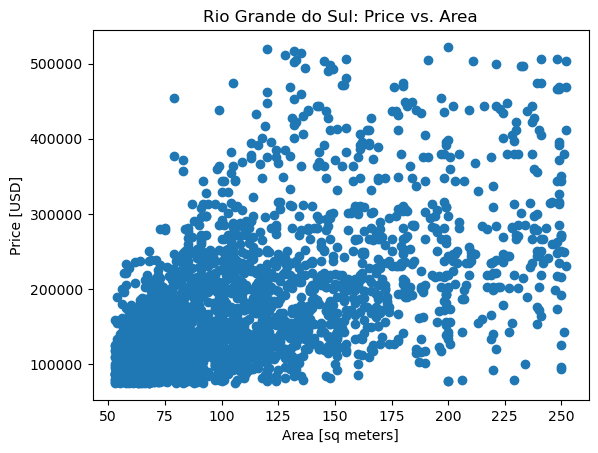

In [30]:
# scatter plot showing the relationship between area and price in the largest state
df_south_rgs = df_south[df_south["state"]=="Rio Grande do Sul"]

# Don't change the code below 👇
fig, ax = plt.subplots()


# Build scatter plot
ax.scatter(
    x=df_south_rgs["area_m2"],
    y=df_south_rgs["price_usd"]
)

# Label axes
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")

# Add title
plt.title("Rio Grande do Sul: Price vs. Area")

In [31]:
"""
Create a dictionary south_states_corr, where the keys are the names of the three states in the "South" 
region of Brazil, and their associated values are the correlation coefficient 
between "area_m2" and "price_usd" in that state.
"""

df_south_large = df_south[df_south["state"]=="Rio Grande do Sul"]

df_south_Santa = df_south[df_south["state"]=="Santa Catarina"]
df_south_Par = df_south[df_south["state"]=="Paraná"]

south_states_corr = {
    "Rio Grande do Sul": df_south_large["area_m2"].corr(
        df_south_large["price_usd"]
    )
}

south_states_corr["Santa Catarina"] = df_south_Santa["area_m2"].corr(df_south_Santa["price_usd"])
south_states_corr["Paraná"] = df_south_Par["area_m2"].corr(df_south_Par["price_usd"])
south_states_corr
print(south_states_corr)

{'Rio Grande do Sul': np.float64(0.5773267433717684), 'Santa Catarina': np.float64(0.5068121776366781), 'Paraná': np.float64(0.5436659935502659)}
